In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Configuration

log_basedir = "../raw_data"
test_runner_log_filename = "test-runner.log"
enforcer_log_filename = "enforcer.log"
asmeta_server_log_filename = "asmeta-server.log"

test_runner_output_filename = "extracted_test_runner_data.csv"
enforcer_output_filename = "extracted_enforcer_data.csv"
asmeta_output_filename = "extracted_asmeta_data.csv"

full_dataset_output_filename = "full_data.csv"
full_aggregated_dataset_output_filename = "full_aggregated_data.csv"

log_pattern = re.compile(
    r"Test #(\d+): time: (.*?) ms"
)
enforcer_delay_pattern = re.compile(r"delay\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
asmeta_server_execution_pattern = re.compile(r"Execution time \(in milliseconds\):\s+([0-9]+(?:\.[0-9]+)?)\s+ms")
ping_log_pattern = re.compile(r"time=([\d.]+)\s*ms")

In [3]:
# Build list of subdirectories under log_basedir
if os.path.exists(log_basedir) and os.path.isdir(log_basedir):
    log_dirs = [
        os.path.join(log_basedir, name)
        for name in sorted(os.listdir(log_basedir))
        if os.path.isdir(os.path.join(log_basedir, name))
    ]
else:
    print(f"Directory not found: {log_basedir}")
    log_dirs = []

print(f"Found {len(log_dirs)} log directories.")

Found 110 log directories.


## Data Collection
### Enforcement Subsystem data
Computed through data obtained by the Test Runner

In [4]:
# Data extraction and file saving

records = []

for log_dir in log_dirs:
    experiment_id = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, test_runner_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        for line in f:
            match = log_pattern.search(line)
            if match:
                test_case_number = int(match.group(1))

                time_ms = match.group(2)

                records.append({
                    "experiment": experiment_id,
                    "test_case_number": test_case_number,
                    "delay_ms": time_ms
                })

df_test_runner_raw = pd.DataFrame(records)
df_test_runner_raw["delay_ms"] = pd.to_numeric(df_test_runner_raw["delay_ms"], errors="coerce")

# df_test_runner_raw

In [5]:
if not df_test_runner_raw.empty:
    test_runner_stats = df_test_runner_raw.groupby("experiment")["delay_ms"].describe()

    test_runner_stats["90%"] = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.90)
    test_runner_stats["95%"] = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.95)
    test_runner_stats["99%"] = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.99)

    test_runner_stats["variance"] = df_test_runner_raw.groupby("experiment")["delay_ms"].var()

    test_runner_stats["skewness"] = df_test_runner_raw.groupby("experiment")["delay_ms"].skew()

    q1 = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.25)
    q2 = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.50)
    q3 = df_test_runner_raw.groupby("experiment")["delay_ms"].quantile(0.75)

    den = q3 - q1
    bowley = (q3 + q1 - 2 * q2) / den
    bowley = bowley.where(den != 0, np.nan)

    test_runner_stats["Bowley_skew"] = bowley

    ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance", "skewness", "Bowley_skew"]
    cols = [c for c in ordered if c in test_runner_stats.columns]
    test_runner_stats = test_runner_stats[cols]

    print("Stats for the enforcement subsystem delay:")
    display(test_runner_stats)

    test_runner_stats.to_csv(test_runner_output_filename)

Stats for the enforcement subsystem delay:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,variance,skewness,Bowley_skew
experiment,,,,,,,,,,,,,,
test_10_10,50.0,88.24,54.128931,64.0,70.00,73.0,79.00,114.4,121.55,334.30,398.0,2929.941224,4.751598,0.333333
test_10_12,50.0,100.74,54.205132,76.0,83.00,85.5,91.50,133.4,148.00,347.94,394.0,2938.196327,4.434733,0.411765
test_10_14,50.0,119.04,46.374676,95.0,101.25,107.5,113.00,150.6,172.40,305.00,403.0,2150.610612,5.063727,-0.063830
test_10_16,50.0,134.88,70.596479,110.0,116.00,119.0,123.75,132.3,163.75,472.93,494.0,4983.862857,4.699676,0.225806
test_10_18,50.0,156.48,57.275289,133.0,141.00,144.0,151.75,165.3,189.85,391.88,533.0,3280.458776,6.113603,0.441860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
test_60_2,50.0,86.66,27.962519,71.0,75.00,78.0,83.00,114.5,124.20,191.22,251.0,781.902449,4.505292,0.250000
test_60_20,50.0,6862.08,148.294363,6778.0,6822.00,6836.5,6850.75,6894.1,6922.40,7454.47,7845.0,21991.217959,6.212542,-0.008696
test_60_4,50.0,168.84,38.004490,149.0,155.00,159.0,164.50,174.5,218.05,331.65,388.0,1444.341224,4.635316,0.157895


### Enforcer data

In [6]:
enforcer_iteration_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, enforcer_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        counter = 0
        for line in f:
            match = enforcer_delay_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                counter += 1
                enforcer_iteration_records.append({
                    "experiment": experiment,
                    "test_case_number": counter,
                    "delay_ms": delay_value,
                })

df_enforcer_raw = pd.DataFrame(enforcer_iteration_records)

In [7]:
if not df_enforcer_raw.empty:
    enforcer_stats = df_enforcer_raw.groupby("experiment")["delay_ms"].describe()

    enforcer_stats["90%"] = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.90)
    enforcer_stats["95%"] = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.95)
    enforcer_stats["99%"] = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.99)

    enforcer_stats["variance"] = df_enforcer_raw.groupby("experiment")["delay_ms"].var()

    enforcer_stats["skewness"] = df_enforcer_raw.groupby("experiment")["delay_ms"].skew()

    q1 = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.25)
    q2 = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.50)
    q3 = df_enforcer_raw.groupby("experiment")["delay_ms"].quantile(0.75)

    den = q3 - q1
    bowley = (q3 + q1 - 2 * q2) / den
    bowley = bowley.where(den != 0, np.nan)

    enforcer_stats["Bowley_skew"] = bowley

    ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance", "skewness", "Bowley_skew"]
    cols = [c for c in ordered if c in enforcer_stats.columns]
    enforcer_stats = enforcer_stats[cols]

    print("Stats for the enforcer delay:")
    display(enforcer_stats)

    enforcer_stats.to_csv(enforcer_output_filename)

Stats for the enforcer delay:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,variance,skewness,Bowley_skew
experiment,,,,,,,,,,,,,,
test_10_10,50.0,59.7946,26.523392,45.05,48.8950,51.160,55.9575,80.674,95.7910,159.1097,217.65,703.490307,4.655569,0.358584
test_10_12,50.0,72.7032,29.117241,57.16,61.8925,63.430,68.9775,94.841,116.5760,185.0652,242.65,847.813732,4.513418,0.565984
test_10_14,50.0,92.4966,34.612625,73.77,78.0375,83.805,89.7975,107.722,140.1715,226.7457,302.73,1198.033790,4.946105,0.019133
test_10_16,50.0,106.8968,45.259273,89.78,94.1000,96.610,100.3250,110.586,142.6625,298.1747,396.65,2048.401769,5.760659,0.193574
test_10_18,50.0,133.1790,53.356406,113.40,117.0425,121.330,128.4375,141.770,162.9510,354.2931,483.07,2846.906017,6.078626,0.247477
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
test_60_2,50.0,62.8708,24.497431,48.19,51.8775,55.015,59.4625,90.108,98.4350,153.5298,201.05,600.124130,4.093215,0.172709
test_60_20,50.0,6833.0856,142.814104,6748.24,6794.1325,6808.695,6822.9625,6863.468,6896.4250,7405.3955,7775.86,20395.868376,6.142713,-0.010232
test_60_4,50.0,145.7710,34.805295,128.99,133.1975,135.295,139.3200,155.521,196.7805,294.9220,337.16,1211.408528,4.298799,0.314822


### ASMETA Server data

In [8]:
asmeta_enforcement_records = []

for log_dir in log_dirs:
    experiment = os.path.basename(log_dir)
    log_path = os.path.join(log_dir, asmeta_server_log_filename)

    if not os.path.exists(log_path):
        print(f"File not found: {log_path}")
        continue

    with open(log_path, "r", encoding="utf-8") as f:
        counter = 0
        for line in f:
            match = asmeta_server_execution_pattern.search(line)
            if match:
                delay_value = float(match.group(1))
                counter += 1
                asmeta_enforcement_records.append({
                    "experiment": experiment,
                    "test_case_number": counter,
                    "delay_ms": delay_value
                })

df_asmeta_raw = pd.DataFrame(asmeta_enforcement_records)

In [9]:
if not df_asmeta_raw.empty:
    asmeta_stats = df_asmeta_raw.groupby("experiment")["delay_ms"].describe()

    asmeta_stats["90%"] = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.90)
    asmeta_stats["95%"] = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.95)
    asmeta_stats["99%"] = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.99)

    asmeta_stats["variance"] = df_asmeta_raw.groupby("experiment")["delay_ms"].var()

    asmeta_stats["skewness"] = df_asmeta_raw.groupby("experiment")["delay_ms"].skew()

    q1 = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.25)
    q2 = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.50)
    q3 = df_asmeta_raw.groupby("experiment")["delay_ms"].quantile(0.75)

    den = q3 - q1
    bowley = (q3 + q1 - 2 * q2) / den
    bowley = bowley.where(den != 0, np.nan)

    asmeta_stats["Bowley_skew"] = bowley

    ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance", "skewness", "Bowley_skew"]
    cols = [c for c in ordered if c in asmeta_stats.columns]
    asmeta_stats = asmeta_stats[cols]

    print("Stats for the asmeta delay:")
    display(asmeta_stats)

    asmeta_stats.to_csv(asmeta_output_filename)

Stats for the asmeta delay:


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,variance,skewness,Bowley_skew
experiment,,,,,,,,,,,,,,
test_10_10,50.0,22.44,14.083077,16.0,17.00,18.0,21.00,33.0,38.00,74.70,109.0,198.333061,5.017529,0.500000
test_10_12,50.0,29.80,18.001134,23.0,23.00,24.0,26.00,43.4,54.00,102.21,137.0,324.040816,4.765820,0.333333
test_10_14,50.0,41.06,23.316290,31.0,32.25,35.0,39.00,52.0,65.95,131.67,189.0,543.649388,5.521233,0.185185
test_10_16,50.0,49.30,32.785792,40.0,41.00,42.0,44.00,47.1,67.60,188.03,263.0,1074.908163,6.032514,0.333333
test_10_18,50.0,62.42,40.669946,50.0,52.00,54.0,56.00,65.9,84.30,227.65,333.0,1654.044490,6.310421,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
test_60_2,50.0,30.62,14.288414,23.0,24.00,25.0,28.75,47.3,51.55,83.03,109.0,204.158776,3.833695,0.578947
test_60_20,50.0,6680.32,124.732111,6604.0,6644.50,6659.5,6673.75,6706.4,6734.25,7173.78,7506.0,15558.099592,6.178709,-0.025641
test_60_4,50.0,108.96,25.311899,98.0,100.00,101.0,104.00,113.8,149.50,218.50,243.0,640.692245,4.131987,0.500000


### Creating full dataset

In [10]:
df_tr = df_test_runner_raw.copy()
df_tr["component"] = "test_runner"

df_enf = df_enforcer_raw.copy()
df_enf["component"] = "enforcer"

df_asm = df_asmeta_raw.copy()
df_asm["component"] = "asmeta"

df_full = pd.concat([df_tr, df_enf, df_asm], ignore_index=True, sort=False)
df_full = df_full[["experiment", "component", "test_case_number", "delay_ms"]]

df_full["rules"] = df_full["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(1)))
df_full["clauses_per_rule"] = df_full["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(2)))
df_full["total_clauses"] = df_full["rules"] * df_full["clauses_per_rule"]

ordered = ["experiment", "component", "rules", "clauses_per_rule", "total_clauses", "test_case_number", "delay_ms"]
cols = [c for c in ordered if c in df_full.columns]
df_full = df_full[cols]

df_full["component"] = pd.Categorical(df_full["component"],
                                     categories=["test_runner", "enforcer", "asmeta"],
                                     ordered=True)
df_full = df_full.sort_values(["component", "total_clauses", "test_case_number"]).reset_index(drop=True)

display(df_full)

df_full.to_csv(full_dataset_output_filename)

,experiment,component,rules,clauses_per_rule,total_clauses,test_case_number,delay_ms
0,test_10_2,test_runner,10,2,20,1,150.0
1,test_10_2,test_runner,10,2,20,2,62.0
2,test_10_2,test_runner,10,2,20,3,66.0
3,test_10_2,test_runner,10,2,20,4,65.0
4,test_10_2,test_runner,10,2,20,5,57.0
...,...,...,...,...,...,...,...
16495,test_60_20,asmeta,60,20,1200,46,6654.0
16496,test_60_20,asmeta,60,20,1200,47,6613.0
16497,test_60_20,asmeta,60,20,1200,48,6643.0
16498,test_60_20,asmeta,60,20,1200,49,6652.0


## Data reporting

In [11]:
per_experiment_df = pd.concat(
    [df_test_runner_raw.groupby("experiment")["delay_ms"].mean().rename("enforcement_subsystem"),
     df_enforcer_raw.groupby("experiment")["delay_ms"].mean().rename("enforcer"),
     df_asmeta_raw.groupby("experiment")["delay_ms"].mean().rename("asmeta_server")],
    axis=1
).reset_index()

per_experiment_df["rules"] = per_experiment_df["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(1)))
per_experiment_df["clauses_per_rule"] = per_experiment_df["experiment"].apply(lambda x: int(re.search(r'_(\d+)_(\d+)$', x).group(2)))
per_experiment_df["total_clauses"] = per_experiment_df["rules"] * per_experiment_df["clauses_per_rule"]

per_experiment_df = per_experiment_df[["experiment", "rules", "clauses_per_rule", "total_clauses", "enforcement_subsystem", "enforcer", "asmeta_server"]].sort_values(by=["total_clauses"])

per_experiment_df

,experiment,rules,clauses_per_rule,total_clauses,enforcement_subsystem,enforcer,asmeta_server
5,test_10_2,10,2,20,52.06,29.0418,3.06
15,test_15_2,15,2,30,56.84,33.1718,5.10
25,test_20_2,20,2,40,53.14,31.2408,6.36
7,test_10_4,10,4,40,65.30,36.2528,6.96
35,test_25_2,25,2,50,54.56,32.8150,7.96
...,...,...,...,...,...,...,...
94,test_55_18,55,18,990,4136.06,4108.6490,3986.06
86,test_50_20,50,20,1000,4271.96,4244.8834,4107.32
104,test_60_18,60,18,1080,5100.96,5072.9712,4941.82
96,test_55_20,55,20,1100,5330.00,5302.2160,5156.44


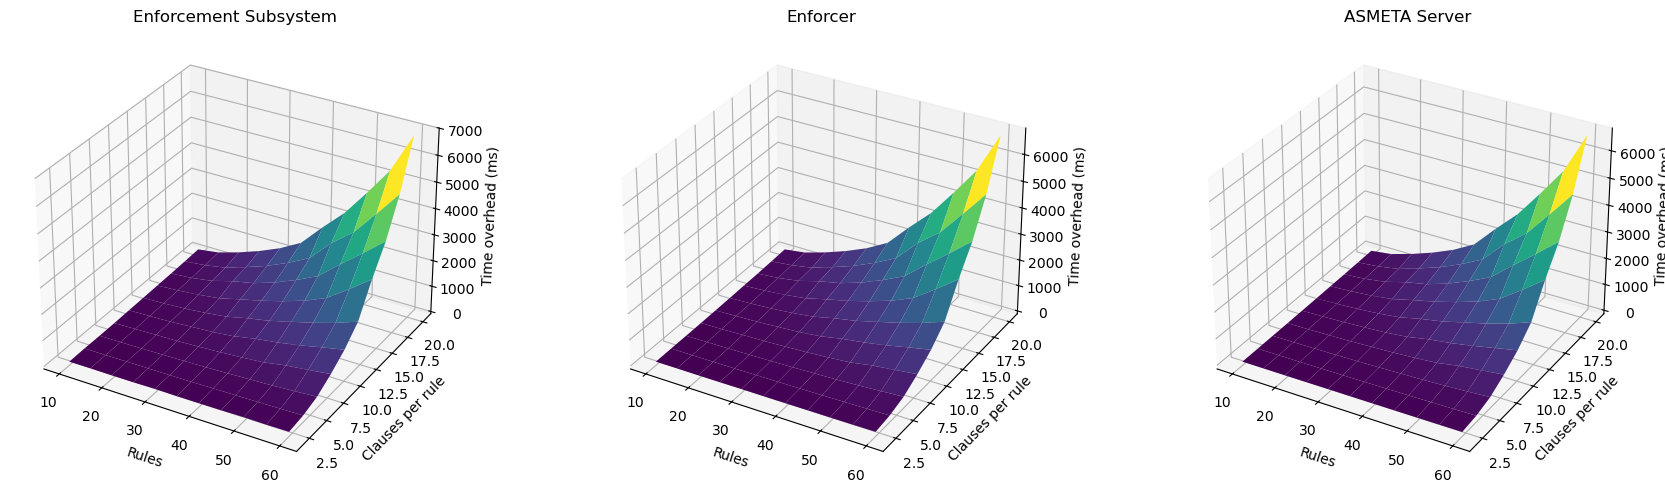

In [12]:
if "per_experiment_df" not in globals():
    raise NameError("per_experiment_df not found in the notebook")

rules = sorted(per_experiment_df["rules"].unique())
clauses = sorted(per_experiment_df["clauses_per_rule"].unique())

# helper to build Z matrix for a column
def build_Z(col):
    lookup = {(r, c): v for r, c, v in zip(per_experiment_df["rules"], per_experiment_df["clauses_per_rule"], per_experiment_df[col])}
    Z = np.array([[lookup.get((r, c), np.nan) for r in rules] for c in clauses])
    return Z

X, Y = np.meshgrid(rules, clauses)  # shape (len(clauses), len(rules))

Z1 = build_Z("enforcement_subsystem")
Z2 = build_Z("enforcer")
Z3 = build_Z("asmeta_server")

fig = plt.figure(figsize=(18, 5))

ax = fig.add_subplot(131, projection="3d")
ax.plot_surface(X, Y, Z1, cmap="viridis", edgecolor="none")
ax.set_title("Enforcement Subsystem")
ax.set_xlabel("Rules"); ax.set_ylabel("Clauses per rule"); ax.set_zlabel("Time overhead (ms)")

ax = fig.add_subplot(132, projection="3d")
ax.plot_surface(X, Y, Z2, cmap="viridis", edgecolor="none")
ax.set_title("Enforcer")
ax.set_xlabel("Rules"); ax.set_ylabel("Clauses per rule"); ax.set_zlabel("Time overhead (ms)")

ax = fig.add_subplot(133, projection="3d")
ax.plot_surface(X, Y, Z3, cmap="viridis", edgecolor="none")
ax.set_title("ASMETA Server")
ax.set_xlabel("Rules"); ax.set_ylabel("Clauses per rule"); ax.set_zlabel("Time overhead (ms)")

plt.tight_layout()

plt.savefig(os.path.join("charts", "components_overhead_heatmaps.pdf"), format="pdf", bbox_inches="tight")

plt.show()

## Analysis

### 1. Data aggregation

In [13]:
aggregate_df = df_full.groupby(["experiment", "component", "rules", "clauses_per_rule", "total_clauses"], observed=True)["delay_ms"].describe()

aggregate_df["90%"] = df_full.groupby(["experiment", "component", "rules", "clauses_per_rule", "total_clauses"], observed=True)["delay_ms"].quantile(0.90)
aggregate_df["95%"] = df_full.groupby(["experiment", "component", "rules", "clauses_per_rule", "total_clauses"], observed=True)["delay_ms"].quantile(0.95)
aggregate_df["99%"] = df_full.groupby(["experiment", "component", "rules", "clauses_per_rule", "total_clauses"], observed=True)["delay_ms"].quantile(0.99)

aggregate_df["variance"] = df_full.groupby(["experiment", "component", "rules", "clauses_per_rule", "total_clauses"], observed=True)["delay_ms"].var()

ordered = ["count", "mean", "std", "min", "25%", "50%", "75%", "90%", "95%", "99%", "max", "variance"]
cols = [c for c in ordered if c in aggregate_df.columns]
aggregate_df = aggregate_df[cols]

aggregate_df.to_csv(full_aggregated_dataset_output_filename)

aggregate_df

count      mean  \
experiment component   rules clauses_per_rule total_clauses                    
test_10_10 test_runner 10    10               100             50.0   88.2400   
           enforcer    10    10               100             50.0   59.7946   
           asmeta      10    10               100             50.0   22.4400   
test_10_12 test_runner 10    12               120             50.0  100.7400   
           enforcer    10    12               120             50.0   72.7032   
...                                                            ...       ...   
test_60_6  enforcer    60    6                360             50.0  327.9180   
           asmeta      60    6                360             50.0  281.7400   
test_60_8  test_runner 60    8                480             50.0  697.1400   
           enforcer    60    8                480             50.0  672.4680   
           asmeta      60    8                480             50.0  616.2800   

                                                                   std  \
experiment component   rules clauses_per_rule total_clauses              
test_10_10 test_runner 10    10               100            54.128931   
           enforcer    10    10               100            26.523392   
           asmeta      10    10               100            14.083077   
test_10_12 test_runner 10    12               120            54.205132   
           enforcer    10    12               120            29.117241   
...                                                                ...   
test_60_6  enforcer    60    6                360            53.993368   
           asmeta      60    6                360            42.295274   
test_60_8  test_runner 60    8                480            66.896207   
           enforcer    60    8                480            63.077141   
           asmeta      60    8                480            50.920522   

                                                                min       25%  \
experiment component   rules clauses_per_rule total_clauses                     
test_10_10 test_runner 10    10               100             64.00   70.0000   
           enforcer    10    10               100             45.05   48.8950   
           asmeta      10    10               100             16.00   17.0000   
test_10_12 test_runner 10    12               120             76.00   83.0000   
           enforcer    10    12               120             57.16   61.8925   
...                                                             ...       ...   
test_60_6  enforcer    60    6                360            308.26  311.1825   
           asmeta      60    6                360            265.00  270.0000   
test_60_8  test_runner 60    8                480            670.00  677.2500   
           enforcer    60    8                480            646.58  653.8725   
           asmeta      60    8                480            595.00  601.0000   

                                                                 50%  \
experiment component   rules clauses_per_rule total_clauses            
test_10_10 test_runner 10    10               100             73.000   
           enforcer    10    10               100             51.160   
           asmeta      10    10               100             18.000   
test_10_12 test_runner 10    12               120             85.500   
           enforcer    10    12               120             63.430   
...                                                              ...   
test_60_6  enforcer    60    6                360            314.440   
           asmeta      60    6                360            271.500   
test_60_8  test_runner 60    8                480            683.500   
           enforcer    60    8                480            659.525   
           asmeta      60    8                480            606.000   

                                                                  

In [14]:
pivot = (
    aggregate_df
    .pivot_table(
        index=["experiment", "rules", "clauses_per_rule", "total_clauses"],
        columns="component",
        values="mean",
        observed=True
    )
    .reset_index()
)

pivot.columns.name = None

pivot["enforcer_only"] = pivot["enforcer"] - pivot["asmeta"]
pivot["test_runner_only"] = pivot["test_runner"] - pivot["enforcer"]

pivot

,experiment,rules,clauses_per_rule,total_clauses,test_runner,enforcer,asmeta,enforcer_only,test_runner_only
0,test_10_10,10,10,100,88.24,59.7946,22.44,37.3546,28.4454
1,test_10_12,10,12,120,100.74,72.7032,29.80,42.9032,28.0368
2,test_10_14,10,14,140,119.04,92.4966,41.06,51.4366,26.5434
3,test_10_16,10,16,160,134.88,106.8968,49.30,57.5968,27.9832
4,test_10_18,10,18,180,156.48,133.1790,62.42,70.7590,23.3010
...,...,...,...,...,...,...,...,...,...
105,test_60_2,60,2,120,86.66,62.8708,30.62,32.2508,23.7892
106,test_60_20,60,20,1200,6862.08,6833.0856,6680.32,152.7656,28.9944
107,test_60_4,60,4,240,168.84,145.7710,108.96,36.8110,23.0690
108,test_60_6,60,6,360,351.90,327.9180,281.74,46.1780,23.9820


### 2. Plotting component overhead vs total number of considered clauses
Investigating the main component causing overhead, and its main causes

In [15]:
palette = sns.color_palette("Set2", 3)
palette.reverse()

labels = ["ASMETA server", "Enforcer", "Enforcement Subsystem"]

#### 2.1 Overhead measured from each component

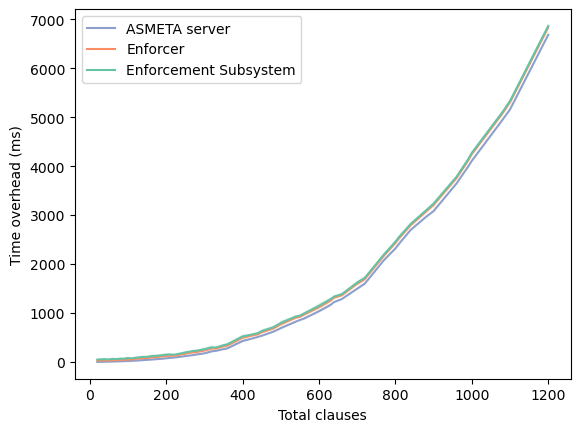

In [16]:
plot_1_data = pivot.melt(
    id_vars=["total_clauses"],
    value_vars=[
        "asmeta",
        "enforcer",
        "test_runner"
    ],
    var_name="component",
    value_name="delay_ms"
)

plt.figure()

ax = sns.lineplot(
    data=plot_1_data,
    x="total_clauses",
    y="delay_ms",
    hue="component",
    palette=palette
)
ax.set_xlabel("Total clauses")
ax.set_ylabel("Time overhead (ms)")

lines = ax.get_lines()
ax.legend(lines, labels)

plt.savefig(os.path.join("charts", "total_overhead.pdf"), format="pdf", bbox_inches="tight")

plt.show()


#### 2.2 Component's overhead contribution

In [17]:
labels = ["ASMETA server", "Enforcer", "Enforcement Subsystem components"]

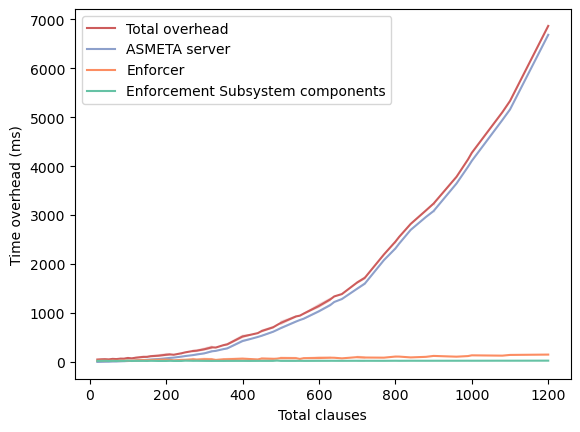

In [18]:
plot_2_data = pivot.melt(
    id_vars=["total_clauses"],
    value_vars=[
        "test_runner",
        "asmeta",
        "enforcer_only",
        "test_runner_only",
    ],
    var_name="component",
    value_name="delay_ms"
)

plt.figure()

ax = sns.lineplot(
    data=plot_2_data,
    x="total_clauses",
    y="delay_ms",
    hue="component",
    palette=["indianred"]+palette
)
ax.set_xlabel("Total clauses")
ax.set_ylabel("Time overhead (ms)")

lines = ax.get_lines()
ax.legend(lines, ["Total overhead"]+labels)

plt.savefig(os.path.join("charts", "components_overhead.pdf"), format="pdf", bbox_inches="tight")

plt.show()


#### 2.3 Focus on first 250 clauses

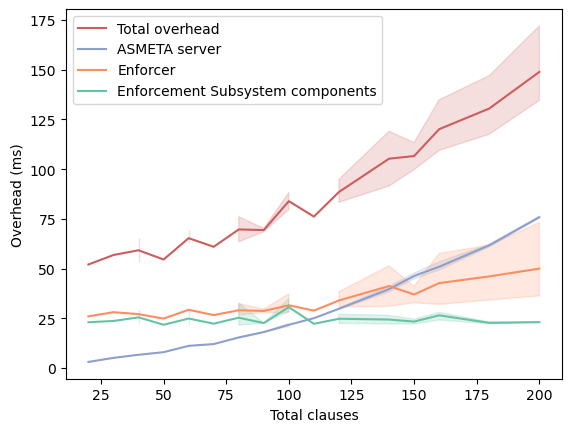

In [19]:
plot_3_data = (
    pivot[pivot["total_clauses"] <= 200]
    .melt(
        id_vars=["total_clauses"],
        value_vars=[
            "test_runner",
            "asmeta",
            "enforcer_only",
            "test_runner_only",
        ],
        var_name="component",
        value_name="delay_ms"
    )
)

# plt.figure(figsize=(2.5, 2))
plt.figure()

ax = sns.lineplot(
    data=plot_3_data,
    x="total_clauses",
    y="delay_ms",
    hue="component",
    palette=["indianred"]+palette,
    # legend=False
)

ax.set_xlabel("Total clauses")
ax.set_ylabel("Overhead (ms)")
# ax.set_xlabel(None)
# ax.set_ylabel(None)

# ax.margins(x=0)

lines = ax.get_lines()
ax.legend(lines, ["Total overhead"]+labels)

plt.savefig(os.path.join("charts", "components_overhead_detail.pdf"), format="pdf", bbox_inches="tight")

plt.show()

#### 2.4 Focus on Enforcer and Test Runner
Check if their overhead grows significantly

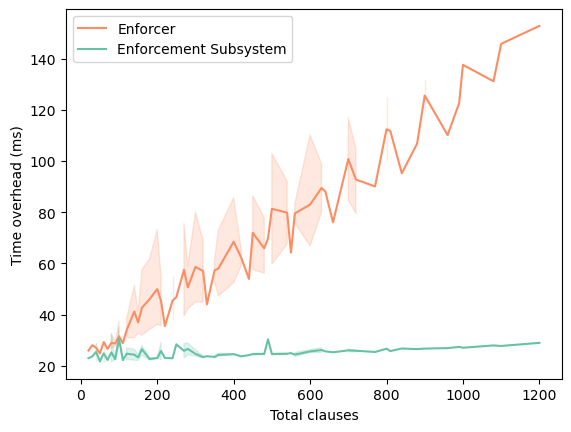

In [20]:
plot_4_data = (
    pivot
    .melt(
        id_vars=["total_clauses"],
        value_vars=["enforcer_only", "test_runner_only"],
        var_name="component",
        value_name="delay_ms"
    )
)

plt.figure()
ax = sns.lineplot(
    data=plot_4_data,
    x="total_clauses",
    y="delay_ms",
    hue="component",
    palette=palette[1:]
)
ax.set_xlabel("Total clauses")
ax.set_ylabel("Time overhead (ms)")

lines = ax.get_lines()
ax.legend(lines, ["Enforcer", "Enforcement Subsystem"])

plt.savefig(os.path.join("charts", "enforcer_overhead_detail.pdf"), format="pdf", bbox_inches="tight")

plt.show()


#### 2.5 Stacking computation times

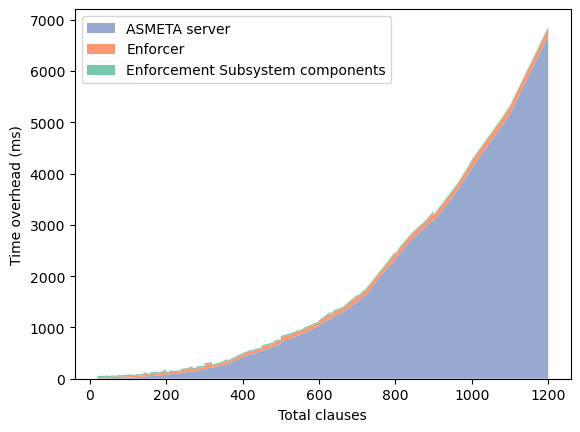

In [21]:
stack = pivot.sort_values("total_clauses")

plt.figure()

plt.stackplot(
    stack["total_clauses"],
    stack["asmeta"],
    stack["enforcer_only"],
    stack["test_runner_only"],
    colors=palette,
    labels=labels,
    alpha=0.9
)
plt.legend(loc="upper left")
plt.xlabel("Total clauses")
plt.ylabel("Time overhead (ms)")

plt.savefig(os.path.join("charts", "components_stacked.pdf"), format="pdf", bbox_inches="tight")

plt.show()


#### 2.6 Overhead per-clause vs number of rules in the model (from ASMETA)

In [22]:
asmeta_analysis_df = pivot.copy()

asmeta_analysis_df["cost_per_clause"] = (
    asmeta_analysis_df["asmeta"] / asmeta_analysis_df["total_clauses"]
)

asmeta_analysis_df

,experiment,rules,clauses_per_rule,total_clauses,test_runner,enforcer,asmeta,enforcer_only,test_runner_only,cost_per_clause
0,test_10_10,10,10,100,88.24,59.7946,22.44,37.3546,28.4454,0.224400
1,test_10_12,10,12,120,100.74,72.7032,29.80,42.9032,28.0368,0.248333
2,test_10_14,10,14,140,119.04,92.4966,41.06,51.4366,26.5434,0.293286
3,test_10_16,10,16,160,134.88,106.8968,49.30,57.5968,27.9832,0.308125
4,test_10_18,10,18,180,156.48,133.1790,62.42,70.7590,23.3010,0.346778
...,...,...,...,...,...,...,...,...,...,...
105,test_60_2,60,2,120,86.66,62.8708,30.62,32.2508,23.7892,0.255167
106,test_60_20,60,20,1200,6862.08,6833.0856,6680.32,152.7656,28.9944,5.566933
107,test_60_4,60,4,240,168.84,145.7710,108.96,36.8110,23.0690,0.454000
108,test_60_6,60,6,360,351.90,327.9180,281.74,46.1780,23.9820,0.782611


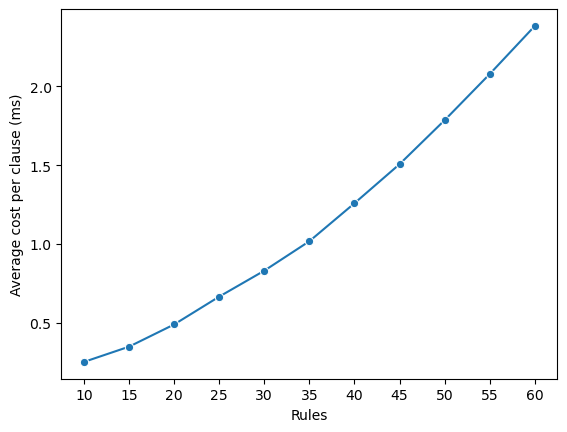

In [23]:
mean_cost_rules = (
    asmeta_analysis_df
    .groupby("rules")["cost_per_clause"]
    .mean()
    .reset_index()
)

plt.figure()
ax = sns.lineplot(
    data=mean_cost_rules,
    x="rules",
    y="cost_per_clause",
    marker="o"
)
ax.set_xlabel("Rules")
ax.set_ylabel("Average cost per clause (ms)")
ax.set_xticks(range(10, 61, 5))

plt.savefig(os.path.join("charts", "asmeta_average_clause_cost_rules.pdf"), format="pdf", bbox_inches="tight")

plt.show()


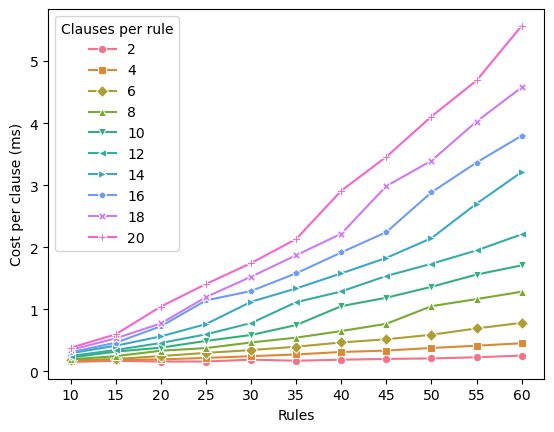

In [24]:
marker_symbols = ["o", "s", "D", "^", "v", "<", ">", "p", "X", "P", "*"]
levels = sorted(asmeta_analysis_df["clauses_per_rule"].unique())
markers = {lvl: marker_symbols[i % len(marker_symbols)] for i, lvl in enumerate(levels)}

plt.figure()
ax = sns.lineplot(
    data=asmeta_analysis_df,
    x="rules",
    y="cost_per_clause",
    hue="clauses_per_rule",
    style="clauses_per_rule",
    markers=markers,
    dashes=False,
    palette=sns.color_palette("husl", len(levels)),
    legend="full"
)

ax.set_xlabel("Rules")
ax.set_xticks(range(10, 61, 5))
ax.set_ylabel("Cost per clause (ms)")
ax.legend(title="Clauses per rule") #, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig(os.path.join("charts", "asmeta_clause_cost_rules.pdf"), format="pdf", bbox_inches="tight")

plt.show()

#### 2.7 Overhead per clause vs number of clauses per rule (ASMETA)

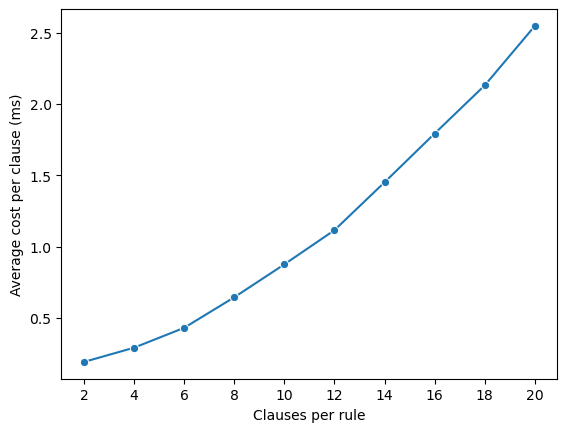

In [25]:
mean_cost_clause_per_rule = (
    asmeta_analysis_df
    .groupby("clauses_per_rule")["cost_per_clause"]
    .mean()
    .reset_index()
)

plt.figure()
ax = sns.lineplot(
    data=mean_cost_clause_per_rule,
    x="clauses_per_rule",
    y="cost_per_clause",
    marker="o"
)
ax.set_xlabel("Clauses per rule")
ax.set_ylabel("Average cost per clause (ms)")
ax.set_xticks(range(2, 21, 2))

plt.savefig(os.path.join("charts", "asmeta_average_clause_cost_clauses.pdf"), format="pdf", bbox_inches="tight")

plt.show()


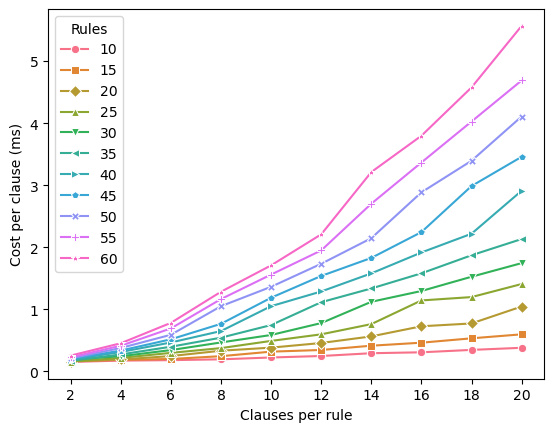

In [26]:
marker_symbols = ["o", "s", "D", "^", "v", "<", ">", "p", "X", "P", "*"]
levels = sorted(asmeta_analysis_df["rules"].unique())
markers = {lvl: marker_symbols[i % len(marker_symbols)] for i, lvl in enumerate(levels)}

plt.figure()
sns.lineplot(
    data=asmeta_analysis_df,
    x="clauses_per_rule",
    y="cost_per_clause",
    hue="rules",
    style="rules",
    markers=markers,
    dashes=False,
    palette=sns.color_palette("husl", len(levels)),
    legend="full"
)

plt.xlabel("Clauses per rule")
plt.xticks(range(2, 21, 2))
plt.ylabel("Cost per clause (ms)")
plt.legend(title="Rules")

plt.savefig(os.path.join("charts", "asmeta_clause_cost_clauses.pdf"), format="pdf", bbox_inches="tight")

plt.show()

In [27]:
## 2.6 and 2.7 together



#### 2.8 Heatmap cost per clause vs rules & clauses per rule (ASMETA)

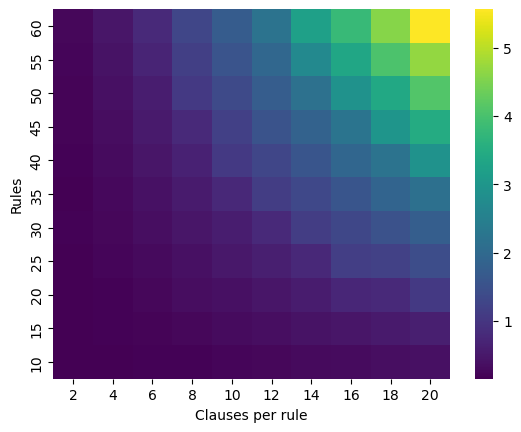

In [28]:
heatmap_data = (
    asmeta_analysis_df
    .pivot(
        index="rules",
        columns="clauses_per_rule",
        values="cost_per_clause"
    )
)

plt.figure()
ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False
)
ax.invert_yaxis()

plt.xlabel("Clauses per rule")
plt.ylabel("Rules")
plt.show()

#### 2.9 Overhead per-clause vs number of rules in the model (from Enforcer only)

In [29]:
enforcer_analysis_df = pivot.copy()

enforcer_analysis_df["cost_per_clause"] = (
    enforcer_analysis_df["enforcer_only"] / enforcer_analysis_df["total_clauses"]
)

enforcer_analysis_df

,experiment,rules,clauses_per_rule,total_clauses,test_runner,enforcer,asmeta,enforcer_only,test_runner_only,cost_per_clause
0,test_10_10,10,10,100,88.24,59.7946,22.44,37.3546,28.4454,0.373546
1,test_10_12,10,12,120,100.74,72.7032,29.80,42.9032,28.0368,0.357527
2,test_10_14,10,14,140,119.04,92.4966,41.06,51.4366,26.5434,0.367404
3,test_10_16,10,16,160,134.88,106.8968,49.30,57.5968,27.9832,0.359980
4,test_10_18,10,18,180,156.48,133.1790,62.42,70.7590,23.3010,0.393106
...,...,...,...,...,...,...,...,...,...,...
105,test_60_2,60,2,120,86.66,62.8708,30.62,32.2508,23.7892,0.268757
106,test_60_20,60,20,1200,6862.08,6833.0856,6680.32,152.7656,28.9944,0.127305
107,test_60_4,60,4,240,168.84,145.7710,108.96,36.8110,23.0690,0.153379
108,test_60_6,60,6,360,351.90,327.9180,281.74,46.1780,23.9820,0.128272


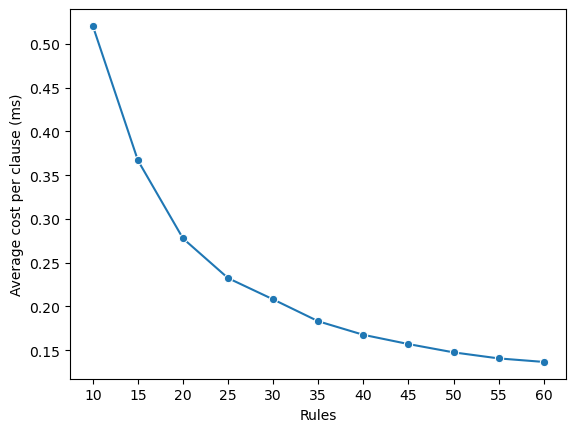

In [30]:
mean_cost_rules = (
    enforcer_analysis_df
    .groupby("rules")["cost_per_clause"]
    .mean()
    .reset_index()
)

plt.figure()
ax = sns.lineplot(
    data=mean_cost_rules,
    x="rules",
    y="cost_per_clause",
    marker="o"
)
ax.set_xlabel("Rules")
ax.set_ylabel("Average cost per clause (ms)")
ax.set_xticks(range(10, 61, 5))

plt.savefig(os.path.join("charts", "enforcer_average_clause_cost_rules.pdf"), format="pdf", bbox_inches="tight")

plt.show()


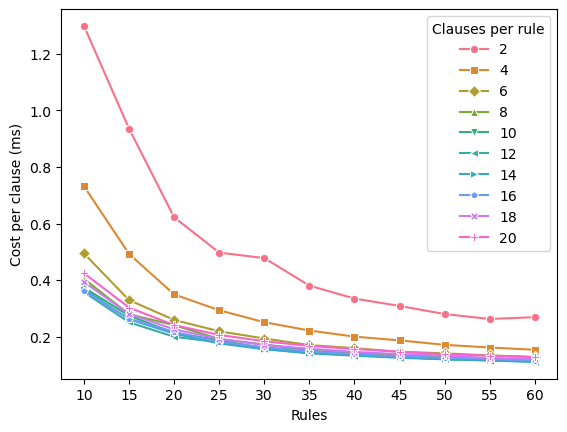

In [31]:
marker_symbols = ["o", "s", "D", "^", "v", "<", ">", "p", "X", "P", "*"]
levels = sorted(enforcer_analysis_df["clauses_per_rule"].unique())
markers = {lvl: marker_symbols[i % len(marker_symbols)] for i, lvl in enumerate(levels)}

plt.figure()
ax = sns.lineplot(
    data=enforcer_analysis_df,
    x="rules",
    y="cost_per_clause",
    hue="clauses_per_rule",
    style="clauses_per_rule",
    markers=markers,
    dashes=False,
    palette=sns.color_palette("husl", len(levels)),
    legend="full"
)

ax.set_xlabel("Rules")
ax.set_xticks(range(10, 61, 5))
ax.set_ylabel("Cost per clause (ms)")
ax.legend(title="Clauses per rule") #, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig(os.path.join("charts", "enforcer_clause_cost_rules.pdf"), format="pdf", bbox_inches="tight")

plt.show()

#### 2.10 Overhead per clause vs number of clauses per rule (from Enforcer only)

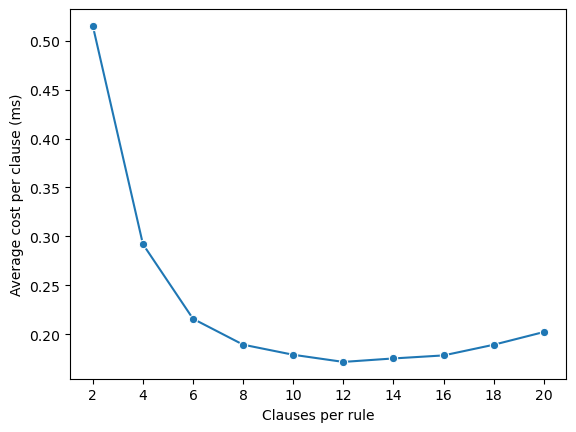

In [32]:
mean_cost_clause_per_rule = (
    enforcer_analysis_df
    .groupby("clauses_per_rule")["cost_per_clause"]
    .mean()
    .reset_index()
)

plt.figure()
ax = sns.lineplot(
    data=mean_cost_clause_per_rule,
    x="clauses_per_rule",
    y="cost_per_clause",
    marker="o"
)
ax.set_xlabel("Clauses per rule")
ax.set_ylabel("Average cost per clause (ms)")
ax.set_xticks(range(2, 21, 2))

plt.savefig(os.path.join("charts", "enforcer_average_clause_cost_rule.pdf"), format="pdf", bbox_inches="tight")

plt.show()


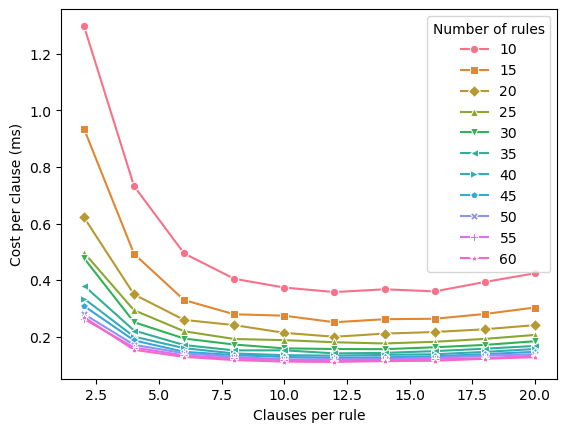

In [33]:
marker_symbols = ["o", "s", "D", "^", "v", "<", ">", "p", "X", "P", "*"]
levels = sorted(enforcer_analysis_df["rules"].unique())
markers = {lvl: marker_symbols[i % len(marker_symbols)] for i, lvl in enumerate(levels)}

plt.figure()
sns.lineplot(
    data=enforcer_analysis_df,
    x="clauses_per_rule",
    y="cost_per_clause",
    hue="rules",
    style="rules",
    markers=markers,
    dashes=False,
    palette=sns.color_palette("husl", len(levels)),
    legend="full"
)

plt.xlabel("Clauses per rule")
ax.set_xticks(range(2, 21, 2))
plt.ylabel("Cost per clause (ms)")
plt.legend(title="Number of rules")

plt.savefig(os.path.join("charts", "enforcer_clause_cost_clauses.pdf"), format="pdf", bbox_inches="tight")

plt.show()

#### 2.11 Heatmap cost per clause vs rules & clauses per rule (from Enforcer only)

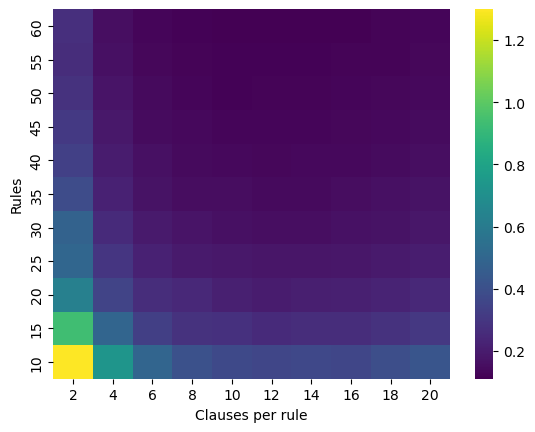

In [34]:
heatmap_data = (
    enforcer_analysis_df
    .pivot(
        index="rules",
        columns="clauses_per_rule",
        values="cost_per_clause"
    )
)

plt.figure()
ax = sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False
)
ax.invert_yaxis()

plt.xlabel("Clauses per rule")
plt.ylabel("Rules")
plt.show()

### 3. Polynomial analysis
Investigating the trend of the overhead introduced by ASMETA (which is the only to be heavily affected by the input size)

#### 3.1 Log-log analysis over the total number of clauses

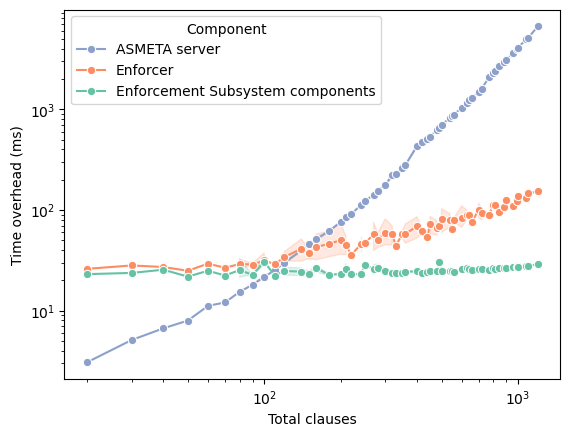

In [35]:
plt.figure()

log_log_plot_data = pivot.melt(
    id_vars=["total_clauses"],
    value_vars=[
        "asmeta",
        "enforcer_only",
        "test_runner_only",
    ],
    var_name="component",
    value_name="delay_ms"
)

ax = sns.lineplot(
    data=log_log_plot_data,
    x="total_clauses",
    y="delay_ms",
    hue="component",
    palette=palette,
    marker="o"
)

plt.xscale("log")
plt.yscale("log")

lines = ax.get_lines()
ax.legend(lines, labels, title="Component")

plt.xlabel("Total clauses")
plt.ylabel("Time overhead (ms)")

plt.savefig(os.path.join("charts", "log_log_overhead.pdf"), format="pdf", bbox_inches="tight")

plt.show()

In [36]:
X = np.log(pivot["total_clauses"].values).reshape(-1, 1)
y = np.log(pivot["asmeta"].values)

model = LinearRegression().fit(X, y)

alpha = model.coef_[0]
r2 = model.score(X, y)

print("Alpha coefficient:", alpha)
print("R² log-log:", r2)

Alpha coefficient: 2.0698588221404215
R² log-log: 0.9783513028303963


#### 3.2 log-linear analysis over the total number of clauses

/var/folders/fw/n2pm2wss0g3294k9bwthxd6h0000gn/T/ipykernel_85658/3129225049.py:3: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(


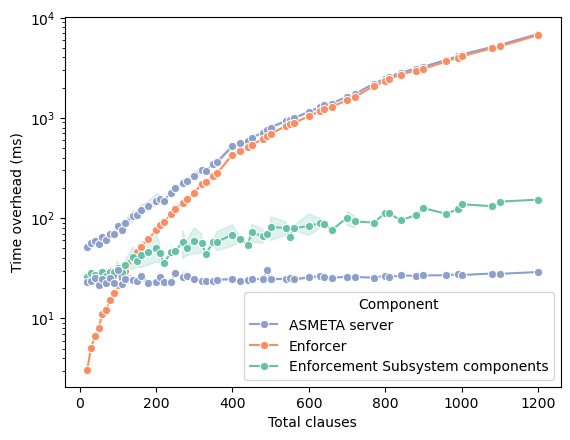

In [37]:
plt.figure()

ax = sns.lineplot(
    data=plot_2_data,
    x="total_clauses",
    y="delay_ms",
    hue="component",
    palette=palette,
    marker="o"
)

# plt.xscale("log")
plt.yscale("log")

lines = ax.get_lines()
ax.legend(lines, labels, title="Component")

plt.xlabel("Total clauses")
plt.ylabel("Time overhead (ms)")

plt.savefig(os.path.join("charts", "log_linear_overhead.pdf"), format="pdf", bbox_inches="tight")

plt.show()

In [38]:
X = pivot["total_clauses"].values.reshape(-1, 1)
y = np.log(pivot["asmeta"].values)

model_exp = LinearRegression().fit(X, y)

print("R² log-linear:", model_exp.score(X, y))

R² log-linear: 0.9069286340648711


#### 3.3 Fitting with polinomial functions
Alpha-coefficient of the log-log is 2: expected qudratic growth

Degree 1 function:
 
3.951 x - 762

Degree 2 function:
          2
0.005895 x - 2.012 x + 194.5

Degree 3 function:
           3            2
2.736e-06 x + 0.001374 x - 0.05367 x + 9.763

Degree 4 function:
            4             3             2
-5.633e-10 x + 4.026e-06 x + 0.0004331 x + 0.1858 x - 5.585



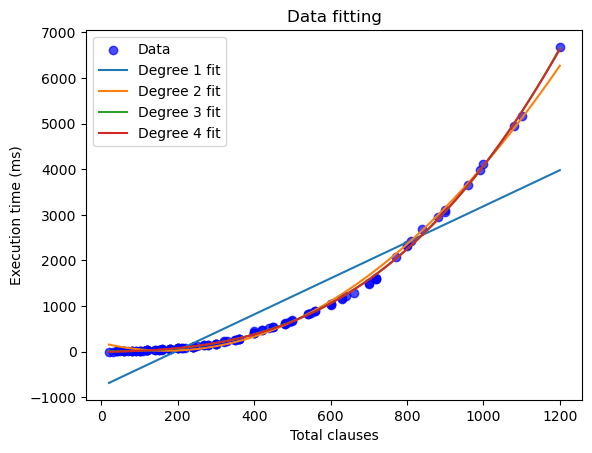

Degree 1: MSE = 266375.7414, R^2 = 0.8222
Degree 2: MSE = 6752.4234, R^2 = 0.9955
Degree 3: MSE = 1326.4342, R^2 = 0.9991
Degree 4: MSE = 1304.4205, R^2 = 0.9991
Best fitting with grade: 4
Best degree: 4, with function:
            4             3             2
-5.633e-10 x + 4.026e-06 x + 0.0004331 x + 0.1858 x - 5.585


In [39]:
X = pivot["total_clauses"].values
y = pivot["asmeta"].values

plt.scatter(X, y, label="Data", color='blue', alpha=0.7)

degrees = [1, 2, 3, 4]
errors = {}
r2_scores = {}

# Fit
x_range = np.linspace(min(X), max(X), 100)

for deg in degrees:
    poly_func = np.poly1d(np.polyfit(X, y, deg))
    print(f"Degree {deg} function:\n{poly_func}\n")
    coeffs = np.polyfit(X, y, deg)
    poly_func = np.poly1d(coeffs)
    
    y_pred = poly_func(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    errors[deg] = mse
    r2_scores[deg] = r2
    
    # Plotting the curve
    plt.plot(x_range, poly_func(x_range), label=f'Degree {deg} fit')

plt.xlabel("Total clauses")
plt.ylabel("Execution time (ms)")
plt.legend()
plt.title("Data fitting")

plt.savefig(os.path.join("charts", "asmeta_data_fitting.pdf"), format="pdf", bbox_inches="tight")

plt.show()

for deg in degrees:
    print(f"Degree {deg}: MSE = {errors[deg]:.4f}, R^2 = {r2_scores[deg]:.4f}")

# R^2 Comparison
best_degree = max(r2_scores, key=r2_scores.get)
print(f"Best fitting with grade: {best_degree}")

# Coefficients
best_coeffs = np.polyfit(X, y, best_degree)
best_poly = np.poly1d(best_coeffs)

print(f"Best degree: {best_degree}, with function:")
print(best_poly)

### 4 Comparison with SLEEC ruleset in the SOTA

In [40]:
sota_ruleset = [
    # {'ruleset': 'DPA', 'rules': 12, 'clauses': 14, 'unless_clauses': 2, 'unless_clauses_per_rule': 0.17, 'clauses_per_rule': 1.17},
    # {'ruleset': 'Aspen', 'rules': 20, 'clauses': 24, 'unless_clauses': 4, 'unless_clauses_per_rule': 0.2, 'clauses_per_rule': 1.2},
    {'ruleset': 'Autocar', 'rules': 39, 'clauses': 58, 'unless_clauses': 19, 'unless_clauses_per_rule': 0.49, 'clauses_per_rule': 1.49},
    # {'ruleset': 'ALMI', 'rules': 27, 'clauses': 35, 'unless_clauses': 8, 'unless_clauses_per_rule': 0.3, 'clauses_per_rule': 1.3},
    # {'ruleset': 'Safescade', 'rules': 23, 'clauses': 26, 'unless_clauses': 3, 'unless_clauses_per_rule': 0.13, 'clauses_per_rule': 1.13},
    # {'ruleset': 'Daisy', 'rules': 23, 'clauses': 41, 'unless_clauses': 18, 'unless_clauses_per_rule': 0.78, 'clauses_per_rule': 1.78},
    # {'ruleset': 'BSN', 'rules': 18, 'clauses': 26, 'unless_clauses': 8, 'unless_clauses_per_rule': 0.44, 'clauses_per_rule': 1.44},
    # {'ruleset': 'CSI', 'rules': 18, 'clauses': 26, 'unless_clauses': 8, 'unless_clauses_per_rule': 0.44, 'clauses_per_rule': 1.44},
    # {'ruleset': 'DressAssist', 'rules': 28, 'clauses': 67, 'unless_clauses': 39, 'unless_clauses_per_rule': 1.39, 'clauses_per_rule': 2.39},
    {'ruleset': 'AssistiveCareRobot', 'rules': 9, 'clauses': 23, 'unless_clauses': 14, 'unless_clauses_per_rule': 1.56, 'clauses_per_rule': 2.56}
]

sota_df = pd.DataFrame(sota_ruleset)

sota_df


,ruleset,rules,clauses,unless_clauses,unless_clauses_per_rule,clauses_per_rule
0,Autocar,39,58,19,0.49,1.49
1,AssistiveCareRobot,9,23,14,1.56,2.56


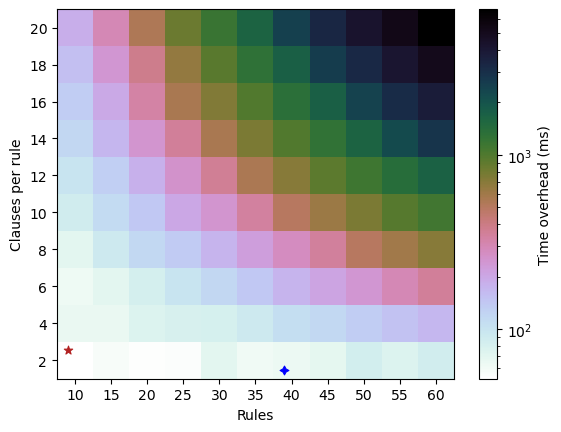

In [41]:
heatmap_data = (
    asmeta_analysis_df
    .pivot(index="clauses_per_rule", columns="rules", values="test_runner")
    .sort_index()
    .sort_index(axis=1)
)

x_vals = heatmap_data.columns.to_numpy()
y_vals = heatmap_data.index.to_numpy()
Z = heatmap_data.to_numpy()

dx = np.diff(x_vals).mean()
dy = np.diff(y_vals).mean()

x0, x1 = x_vals.min() - dx/2, x_vals.max() + dx/2
y0, y1 = y_vals.min() - dy/2, y_vals.max() + dy/2

positive_mask = Z > 0
norm = LogNorm(vmin=max(Z[positive_mask].min(), 1e-6), vmax=Z.max()) if positive_mask.any() else None

Z_masked = np.ma.masked_invalid(Z)
# cmap = plt.cm.viridis.copy()
# cmap.set_bad(alpha=0.0)

cmap = sns.color_palette("cubehelix", as_cmap=True).reversed()
# cmap = sns.color_palette("hls", as_cmap=True)

plt.figure()

im = plt.imshow(
    Z_masked,
    origin="lower",
    aspect="auto",
    extent=[x0, x1, y0, y1],
    interpolation="nearest",
    cmap=cmap,
    norm=norm
)

plt.colorbar(im, label="Time overhead (ms)")

plt.scatter(
    sota_df["rules"][:-1],
    sota_df["clauses_per_rule"][:-1],
    s=40, c="blue",
    linewidths=0.8, marker=(4,1,0), zorder=10
)

plt.scatter(
    sota_df["rules"].iloc[-1],
    sota_df["clauses_per_rule"].iloc[-1],
    s=40, c="firebrick",
    linewidths=0.8, marker="*", zorder=10
)

plt.xlabel("Rules")
plt.ylabel("Clauses per rule")

plt.xticks(x_vals)
plt.yticks(y_vals)

plt.xlim(x0, x1)
plt.ylim(y0, y1)

plt.savefig(os.path.join("charts", "sota_heatmap.pdf"), format="pdf", bbox_inches="tight")

plt.show()